***Assignments 08:- Train a Decision Tree or Logistic Regression model on basic URL features (e.g., presence of "https",
number of subdomains) to classify phishing websites.<br>***

**Name:-Vaishnavi Sharad Gavali <br>**
**Div:-TY-AIDS-A (C) <br>**
**Roll No:-EN24107044**

In [11]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix, classification_report



In [5]:
# Load Dataset
df = pd.read_csv("Phishing_Websites_Data.csv")

print("First 5 Rows")
print(df.head())

# Missing Values
print("\nMissing Values")
print(df.isnull().sum())

df = df.fillna(0)


First 5 Rows
   having_IP_Address  URL_Length  Shortining_Service  having_At_Symbol  \
0                 -1           1                   1                 1   
1                  1           1                   1                 1   
2                  1           0                   1                 1   
3                  1           0                   1                 1   
4                  1           0                  -1                 1   

   double_slash_redirecting  Prefix_Suffix  having_Sub_Domain  SSLfinal_State  \
0                        -1             -1                 -1              -1   
1                         1             -1                  0               1   
2                         1             -1                 -1              -1   
3                         1             -1                 -1              -1   
4                         1             -1                  1               1   

   Domain_registeration_length  Favicon  ...  popUpWidn

In [6]:
X = df.drop("Result", axis=1)
Y = df["Result"]

# Split Data
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [7]:
model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=6,
    random_state=42
)

model.fit(X_train, Y_train)

print("\nModel Training Completed")

# Prediction
Y_pred = model.predict(X_test)



Model Training Completed


In [8]:
accuracy = accuracy_score(Y_test, Y_pred)
precision = precision_score(Y_test, Y_pred, average="weighted")
recall = recall_score(Y_test, Y_pred, average="weighted")
f1 = f1_score(Y_test, Y_pred, average="weighted")

print("\nEvaluation Results")
print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))



Evaluation Results
Accuracy : 0.9371
Precision: 0.9371
Recall   : 0.9371
F1 Score : 0.9371


In [9]:
cm = confusion_matrix(Y_test, Y_pred)

print("\nConfusion Matrix")
print(cm)

# Classification Report
print("\nClassification Report")
print(classification_report(Y_test, Y_pred))

# Wrong Predictions
wrong = X_test.copy()
wrong["Actual"] = Y_test.values
wrong["Predicted"] = Y_pred



Confusion Matrix
[[ 885   71]
 [  68 1187]]

Classification Report
              precision    recall  f1-score   support

          -1       0.93      0.93      0.93       956
           1       0.94      0.95      0.94      1255

    accuracy                           0.94      2211
   macro avg       0.94      0.94      0.94      2211
weighted avg       0.94      0.94      0.94      2211



In [10]:
wrong = wrong[wrong["Actual"] != wrong["Predicted"]]

print("\nIncorrect Predictions")
print(wrong.head())

# Conclusion
print("\nConclusion")
print("The selected URL features are useful for phishing website classification.")


Incorrect Predictions
       having_IP_Address  URL_Length  Shortining_Service  having_At_Symbol  \
10806                 -1           1                   1                 1   
1470                   1          -1                   1                 1   
1795                   1          -1                   1                 1   
8613                  -1          -1                   1                 1   
6286                  -1          -1                   1                 1   

       double_slash_redirecting  Prefix_Suffix  having_Sub_Domain  \
10806                         1             -1                  1   
1470                          1             -1                  1   
1795                          1             -1                  0   
8613                          1             -1                  0   
6286                          1             -1                  0   

       SSLfinal_State  Domain_registeration_length  Favicon  ...  Iframe  \
10806            

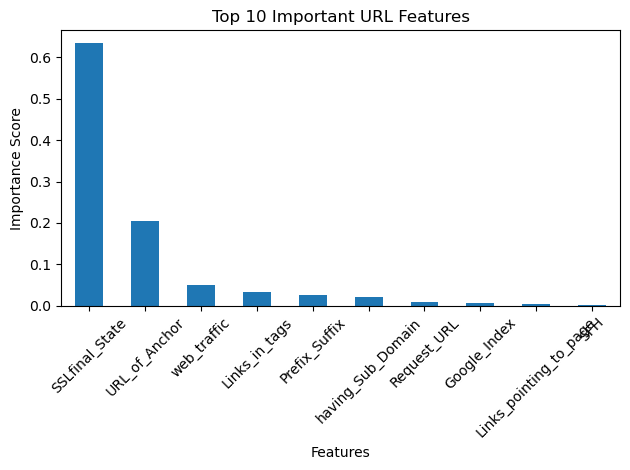

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)

importance.sort_values(ascending=False).head(10).plot(kind="bar")

plt.title("Top 10 Important URL Features")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

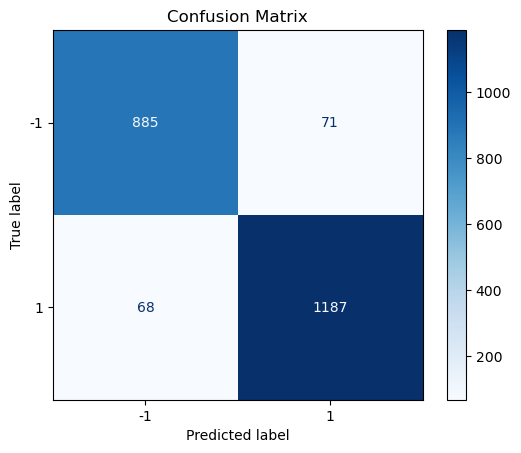

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test, Y_test, cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

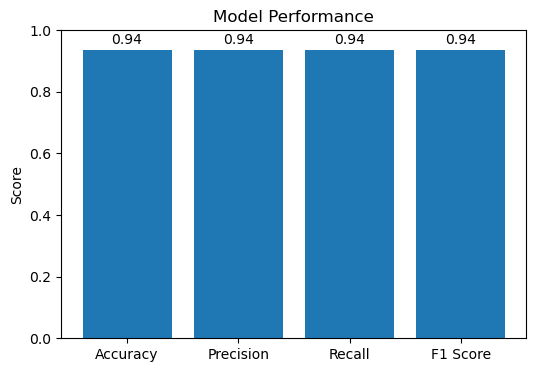

In [14]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
values = [accuracy, precision, recall, f1]

plt.figure(figsize=(6,4))
plt.bar(metrics, values)

plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Model Performance")

for i, value in enumerate(values):
    plt.text(i, value+0.02, f"{value:.2f}", ha="center")

plt.show()

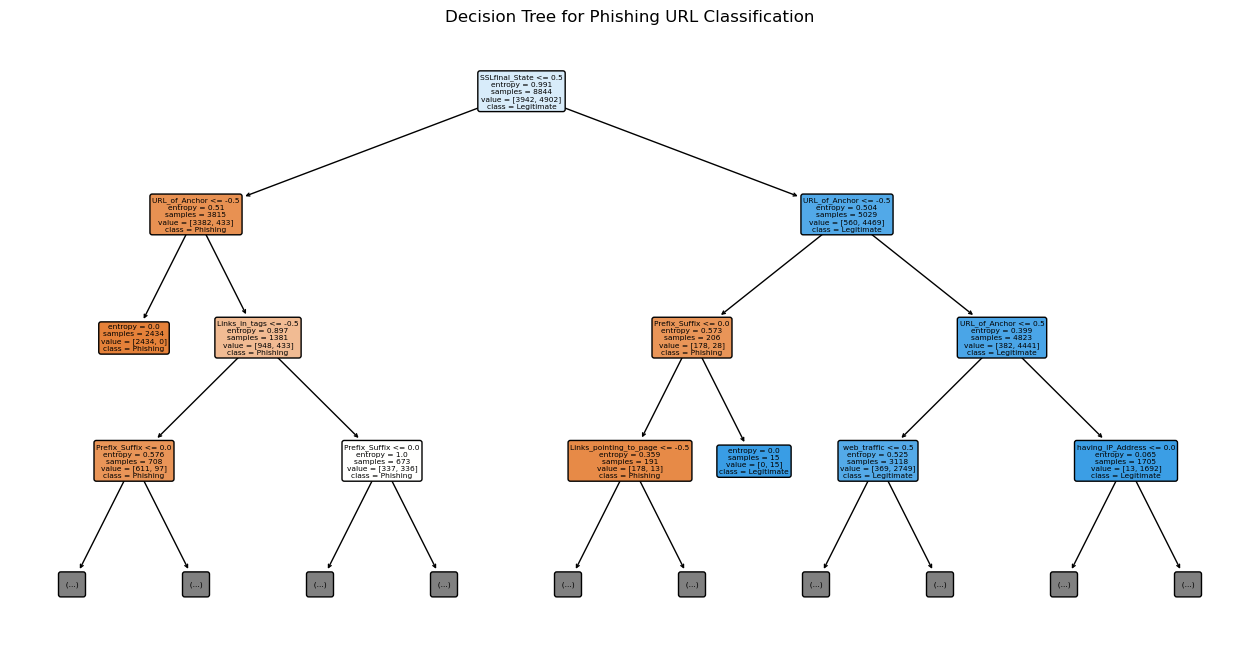

In [15]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(16,8))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Phishing","Legitimate"],
    filled=True,
    rounded=True,
    max_depth=3
)

plt.title("Decision Tree for Phishing URL Classification")
plt.show()